# Exercício:

## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que não há uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

## 01 – Descreva o racional da sua resposta:

R.: Como não existe uma hierarquia entre as variáveis (nominais), consideramos apenas as frequências simples dos valores, com isso:

1 - importar as bibliotecas pandas, numpy e matplotlib, assim como o arquivo com os valores.

2 - contar os valores (value_counts) presentes na coluna de numero de caracteres.

3 - a partir desses valores de frequencia, plotar o gráfico.

## 02 – Desenhe o fluxograma da resposta:

<img src="./img/lista13_exercicio2.png" width="400" />

## 03 – Escreva o programa em Python:

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df_ex3 = pd.read_csv('df_exerc7.csv', index_col=0, header=0)
df_ex3

,numero_caracteres,primeiras_letras,letras_a,presenca_hu
interleucina_6,14,in,1,False
interferon_gama,15,in,2,False
TNF-alpha,9,TN,2,False
interleucina_12,15,in,1,False
TGF-beta,8,TG,1,False


In [5]:
freq = df_ex3['numero_caracteres'].value_counts().sort_index()
print(freq)
freq_df = freq.reset_index()
freq_df.columns = ['numero_caracteres', 'frequencia_1']
print(freq_df)

numero_caracteres
8     1
9     1
14    1
15    2
Name: count, dtype: int64
   numero_caracteres  frequencia_1
0                  8             1
1                  9             1
2                 14             1
3                 15             2


In [6]:
df_ex3 = df_ex3.join(freq_df.set_index("numero_caracteres"), on="numero_caracteres")
print(df_ex3)

                 numero_caracteres primeiras_letras  letras_a  presenca_hu  \
interleucina_6                  14               in         1        False   
interferon_gama                 15               in         2        False   
TNF-alpha                        9               TN         2        False   
interleucina_12                 15               in         1        False   
TGF-beta                         8               TG         1        False   

                 frequencia_1  
interleucina_6              1  
interferon_gama             2  
TNF-alpha                   1  
interleucina_12             2  
TGF-beta                    1  


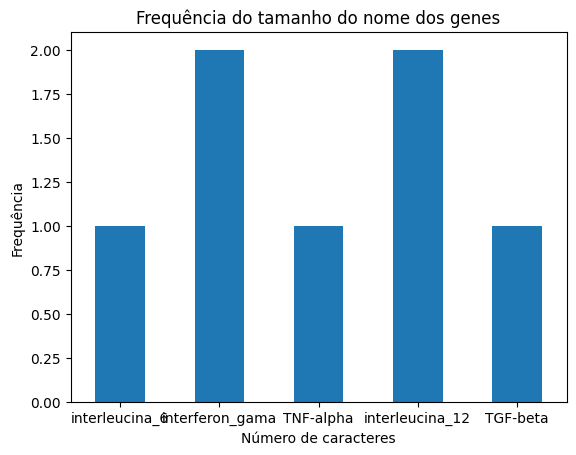

In [7]:
df_ex3['frequencia_1'].plot(kind="bar")

plt.xticks(rotation=0)
plt.xlabel("Número de caracteres")
plt.ylabel("Frequência")
plt.title("Frequência do tamanho do nome dos genes")

plt.show()

## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que à uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

## 04 – Descreva o racional da sua resposta:

R.: No caso de variáveis qualitativas ordinais (que possuem ordem entre si), faz sentido calcular, além da frequência simples, a frequência acumulada, por isso:

1 - agrupar os valores da coluna de número de caracteres, utilizando groupby, para obter uma única frequência para cada valor distinto.

2 - aplicar a soma acumulada (cumsum) sobre essas frequências, respeitando a ordem crescente dos valores.

3 - plotar o gráfico a partir da coluna de frequência acumulada.

## 05 – Desenhe o fluxograma da resposta:

<img src="./img/lista13_exercicio5.png" width="400" />

## 06 – Escreva o programa em Python:

In [8]:
df_ex3['frequencia_acumulada_1'] = (
    df_ex3['numero_caracteres']
    .map(df_ex3.groupby('numero_caracteres')
['frequencia_1'].first().cumsum())
)

print(df_ex3)

                 numero_caracteres primeiras_letras  letras_a  presenca_hu  \
interleucina_6                  14               in         1        False   
interferon_gama                 15               in         2        False   
TNF-alpha                        9               TN         2        False   
interleucina_12                 15               in         1        False   
TGF-beta                         8               TG         1        False   

                 frequencia_1  frequencia_acumulada_1  
interleucina_6              1                       3  
interferon_gama             2                       5  
TNF-alpha                   1                       2  
interleucina_12             2                       5  
TGF-beta                    1                       1  


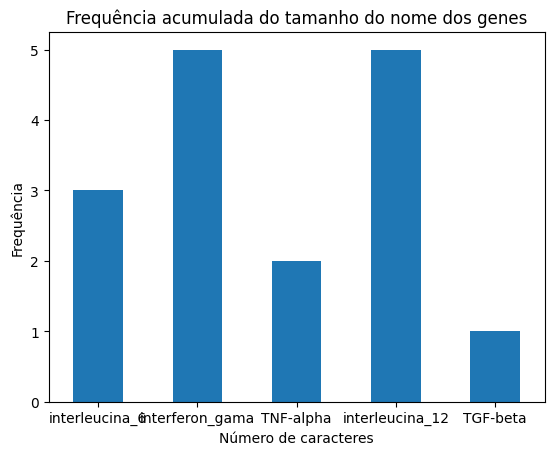

In [9]:
df_ex3['frequencia_acumulada_1'].plot(kind="bar")

plt.xticks(rotation=0)
plt.xlabel("Número de caracteres")
plt.ylabel("Frequência")
plt.title("Frequência acumulada do tamanho do nome dos genes")

plt.show()

## 07 – Reorganize a DataFrame, removendo as colunas contendo os dois primeiros caracteres, o número de caracter 'a', e a presença de 'hu', dos genes. Renomeie as colunas de acordo com as informações. Adicione uma coluna com a informação de 'Amostra 1'.

In [11]:
df_ex7 = df_ex3.drop(columns=['primeiras_letras', "letras_a", "presenca_hu"])
print(df_ex7)

                 numero_caracteres  frequencia_1  frequencia_acumulada_1
interleucina_6                  14             1                       3
interferon_gama                 15             2                       5
TNF-alpha                        9             1                       2
interleucina_12                 15             2                       5
TGF-beta                         8             1                       1


In [12]:
df_ex7 = df_ex7.rename(columns={"numero_caracteres": "Amostra1"})
df_ex7

,Amostra1,frequencia_1,frequencia_acumulada_1
interleucina_6,14,1,3
interferon_gama,15,2,5
TNF-alpha,9,1,2
interleucina_12,15,2,5
TGF-beta,8,1,1


## 08 – Usando a função randint(), da classe random do módulo numpy (np.random.randint(1,10,5)), instancie objeto da classe numpy array. Calcule as frequências desta nova amostra, considerando que à uma ordem entre os genes. Insira na DataFrame este objeto como "Amostra 2".

In [13]:
df_ex7['Amostra2'] = np.random.randint(1, 10, len(df_ex7))
freq2 = df_ex7['Amostra2'].value_counts().sort_index()
df_ex7['frequencia_2'] = df_ex7['Amostra2'].map(freq2)

freq2_acum = freq2.cumsum()
df_ex7['frequencia_acumulada_2'] = df_ex7['Amostra2'].map(freq2_acum)

df_ex7

,Amostra1,frequencia_1,frequencia_acumulada_1,Amostra2,frequencia_2,frequencia_acumulada_2
interleucina_6,14,1,3,3,2,2
interferon_gama,15,2,5,3,2,2
TNF-alpha,9,1,2,6,1,3
interleucina_12,15,2,5,8,1,4
TGF-beta,8,1,1,9,1,5


## 09 – Repita o exercício 8, inserindo na DataFrame as replicas "Amostra 3“, "Amostra 4“, "Amostra 5“ e "Amostra 6".

In [14]:
for i in range(3, 7):
    col_amostra = f'Amostra {i}'
    col_freq = f'frequencia_{i}'
    col_freq_acum = f'frequencia_acumulada_{i}'

    df_ex7[col_amostra] = np.random.randint(1, 10, len(df_ex7))

    freq = df_ex7[col_amostra].value_counts().sort_index()
    df_ex7[col_freq] = df_ex7[col_amostra].map(freq)

    freq_acum = freq.cumsum()
    df_ex7[col_freq_acum] = df_ex7[col_amostra].map(freq_acum)

df_ex7

,Amostra1,frequencia_1,frequencia_acumulada_1,Amostra2,frequencia_2,frequencia_acumulada_2,Amostra 3,frequencia_3,frequencia_acumulada_3,Amostra 4,frequencia_4,frequencia_acumulada_4,Amostra 5,frequencia_5,frequencia_acumulada_5,Amostra 6,frequencia_6,frequencia_acumulada_6
interleucina_6,14,1,3,3,2,2,1,1,1,8,1,5,9,1,5,4,1,3
interferon_gama,15,2,5,3,2,2,6,1,3,2,2,3,2,1,1,3,1,2
TNF-alpha,9,1,2,6,1,3,4,1,2,1,1,1,4,1,3,1,1,1
interleucina_12,15,2,5,8,1,4,7,1,4,5,1,4,3,1,2,5,1,4
TGF-beta,8,1,1,9,1,5,8,1,5,2,2,3,7,1,4,7,1,5


## 10 – Obtenha dos seus dados o gráfico abaixo, adicionando 3 replicas.

In [15]:
replicas = []

for replica in range(1, 4):
    for i in range(1,6):
        amostra = np.random.randint(1, 10, len(df_ex7))
        freq = pd.Series(amostra).value_counts().sort_index()
        freq_map = pd.Series(amostra).map(freq)
        temp = pd.DataFrame({
            'index': df_ex7.index,
            'Frequência': freq_map,
            'Amostras': f'Amostra {i}',
            'Réplicas': f'replica {replica}'
        })
        replicas.append(temp)
df_ex10 = pd.concat(replicas).reset_index(drop=True)

In [16]:
import seaborn as sns

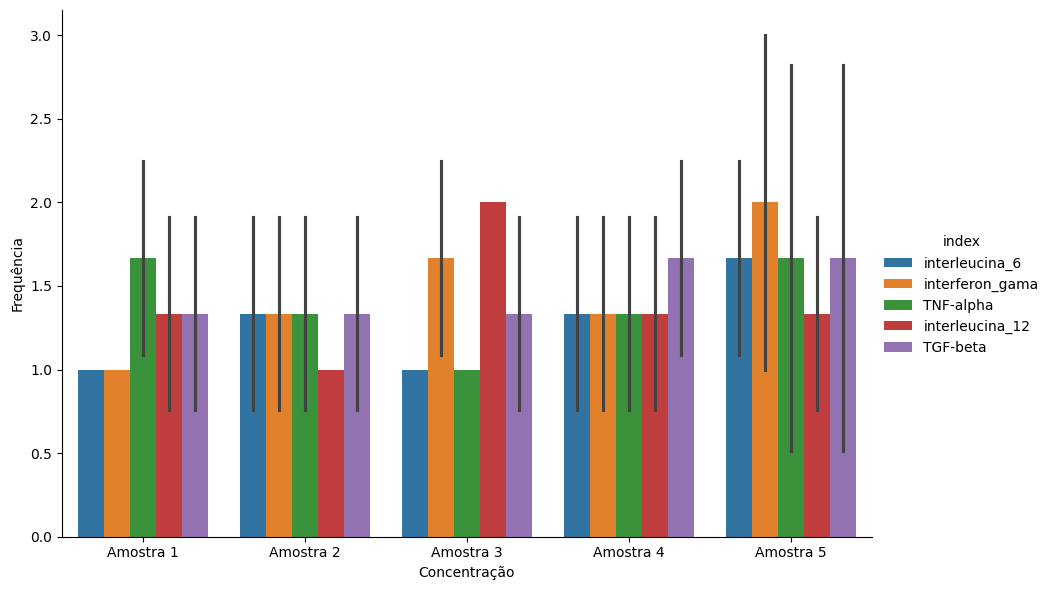

In [20]:
sns.catplot(
    kind='bar',
    x='Amostras',
    y='Frequência',
    hue='index',
    errorbar='sd',
    height=6,
    aspect=1.5,
    data=df_ex10
)

plt.xlabel('Concentração')
plt.ylabel('Frequência')

plt.show()